# LeetCode #159: Longest Substring with At Most Two Distinct Characters

https://leetcode.com/problems/longest-substring-with-at-most-two-distinct-characters/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(1)$ |
| **Optimal: Sliding Window** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Check every possible substring by iterating start and end indices. For each substring, count distinct characters. If at most 2, update the max length. This is $O(n^2)$ time.

### Optimal: Sliding Window ★
Use two pointers (`left`, `right`) and a hash map tracking character counts in the current window.
1. Expand `right` — add `s[right]` to the map.
2. When the map has more than 2 distinct characters, shrink from `left`: decrement `s[left]`'s count, remove it from the map if count reaches 0, then increment `left`.
3. Update `maxLen = max(maxLen, right - left + 1)` at each step.

**Why this works:** The window always contains at most 2 distinct characters. Each character is added and removed at most once, so total work is $O(n)$.

**Constraints:**
* `1 <= s.length <= 10^5`

## Solutions

### C#

In [ ]:
public class Solution {
    public int LengthOfLongestSubstringTwoDistinct(string s) {
        var count = new Dictionary<char, int>();
        int left = 0, maxLen = 0;
        
        for (int right = 0; right < s.Length; right++) {
            count[s[right]] = count.GetValueOrDefault(s[right], 0) + 1;
            
            while (count.Count > 2) {
                count[s[left]]--;
                if (count[s[left]] == 0) count.Remove(s[left]);
                left++;
            }
            
            maxLen = Math.Max(maxLen, right - left + 1);
        }
        
        return maxLen;
    }
}

### Python

In [ ]:
from collections import defaultdict

class Solution:
    def lengthOfLongestSubstringTwoDistinct(self, s: str) -> int:
        count = defaultdict(int)
        left = 0
        max_len = 0
        
        for right in range(len(s)):
            count[s[right]] += 1
            
            while len(count) > 2:
                count[s[left]] -= 1
                if count[s[left]] == 0:
                    del count[s[left]]
                left += 1
            
            max_len = max(max_len, right - left + 1)
        
        return max_len

### Go

In [ ]:
func lengthOfLongestSubstringTwoDistinct(s string) int {
    count := make(map[byte]int)
    left, maxLen := 0, 0
    
    for right := 0; right < len(s); right++ {
        count[s[right]]++
        
        for len(count) > 2 {
            count[s[left]]--
            if count[s[left]] == 0 {
                delete(count, s[left])
            }
            left++
        }
        
        if right-left+1 > maxLen {
            maxLen = right - left + 1
        }
    }
    
    return maxLen
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn length_of_longest_substring_two_distinct(s: String) -> i32 {
        let s = s.as_bytes();
        let mut count: HashMap<u8, i32> = HashMap::new();
        let mut left = 0;
        let mut max_len = 0;
        
        for right in 0..s.len() {
            *count.entry(s[right]).or_insert(0) += 1;
            
            while count.len() > 2 {
                let c = s[left];
                *count.get_mut(&c).unwrap() -= 1;
                if count[&c] == 0 {
                    count.remove(&c);
                }
                left += 1;
            }
            
            max_len = max_len.max(right - left + 1);
        }
        
        max_len as i32
    }
}

## Example Scenarios

1. **Common Case:** `s = "eceba"` $\Rightarrow$ `3`. The sliding window expands to `"ece"` (2 distinct chars: {e, c}), then at index 3 ('b') the window has 3 distinct chars, so we shrink left. Best window length = $3$. Straightforward application of the expand/shrink pattern.

2. **Slightly Complex:** `s = "abcbbbbcccbdddadacb"` $\Rightarrow$ `10`. Multiple candidate windows compete. The longest valid window is `"bcbbbbcccb"` (indices 1-10, chars {b, c}). WHY tricky: many overlapping segments with shared characters; the window must not shrink prematurely.

3. **Edge Case (Time):** `s = "abababab...ab"` (length $10^5$, alternating 'a' and 'b') $\Rightarrow$ $10^5$. Only 2 distinct chars, so the window never shrinks. Each of $n = 10^5$ characters is visited exactly once. Total work: $O(10^5)$. WHY tricky: worst-case input size with best-case behavior — left pointer never moves.

4. **Edge Case (Space):** `s = "abcabc...abc"` (length $10^5$, repeating 3-char pattern) $\Rightarrow$ `2`. Every window of length $\geq 3$ has 3 distinct chars. The hash map oscillates between 2 and 3 entries, maximizing insert/delete churn: $2 \times 10^5$ map operations total. Space is bounded at $O(1)$ (at most 3 keys).

5. **Almost-Impossible but Plausible:** `s = "a"` (single character, $n = 1$) $\Rightarrow$ `1`. The window starts and ends at index 0. The while-loop condition `map.size > 2` never triggers. Result: $\text{right} - \text{left} + 1 = 0 - 0 + 1 = 1$. WHY tricky: minimum boundary input; tests for off-by-one errors in window size calculation.

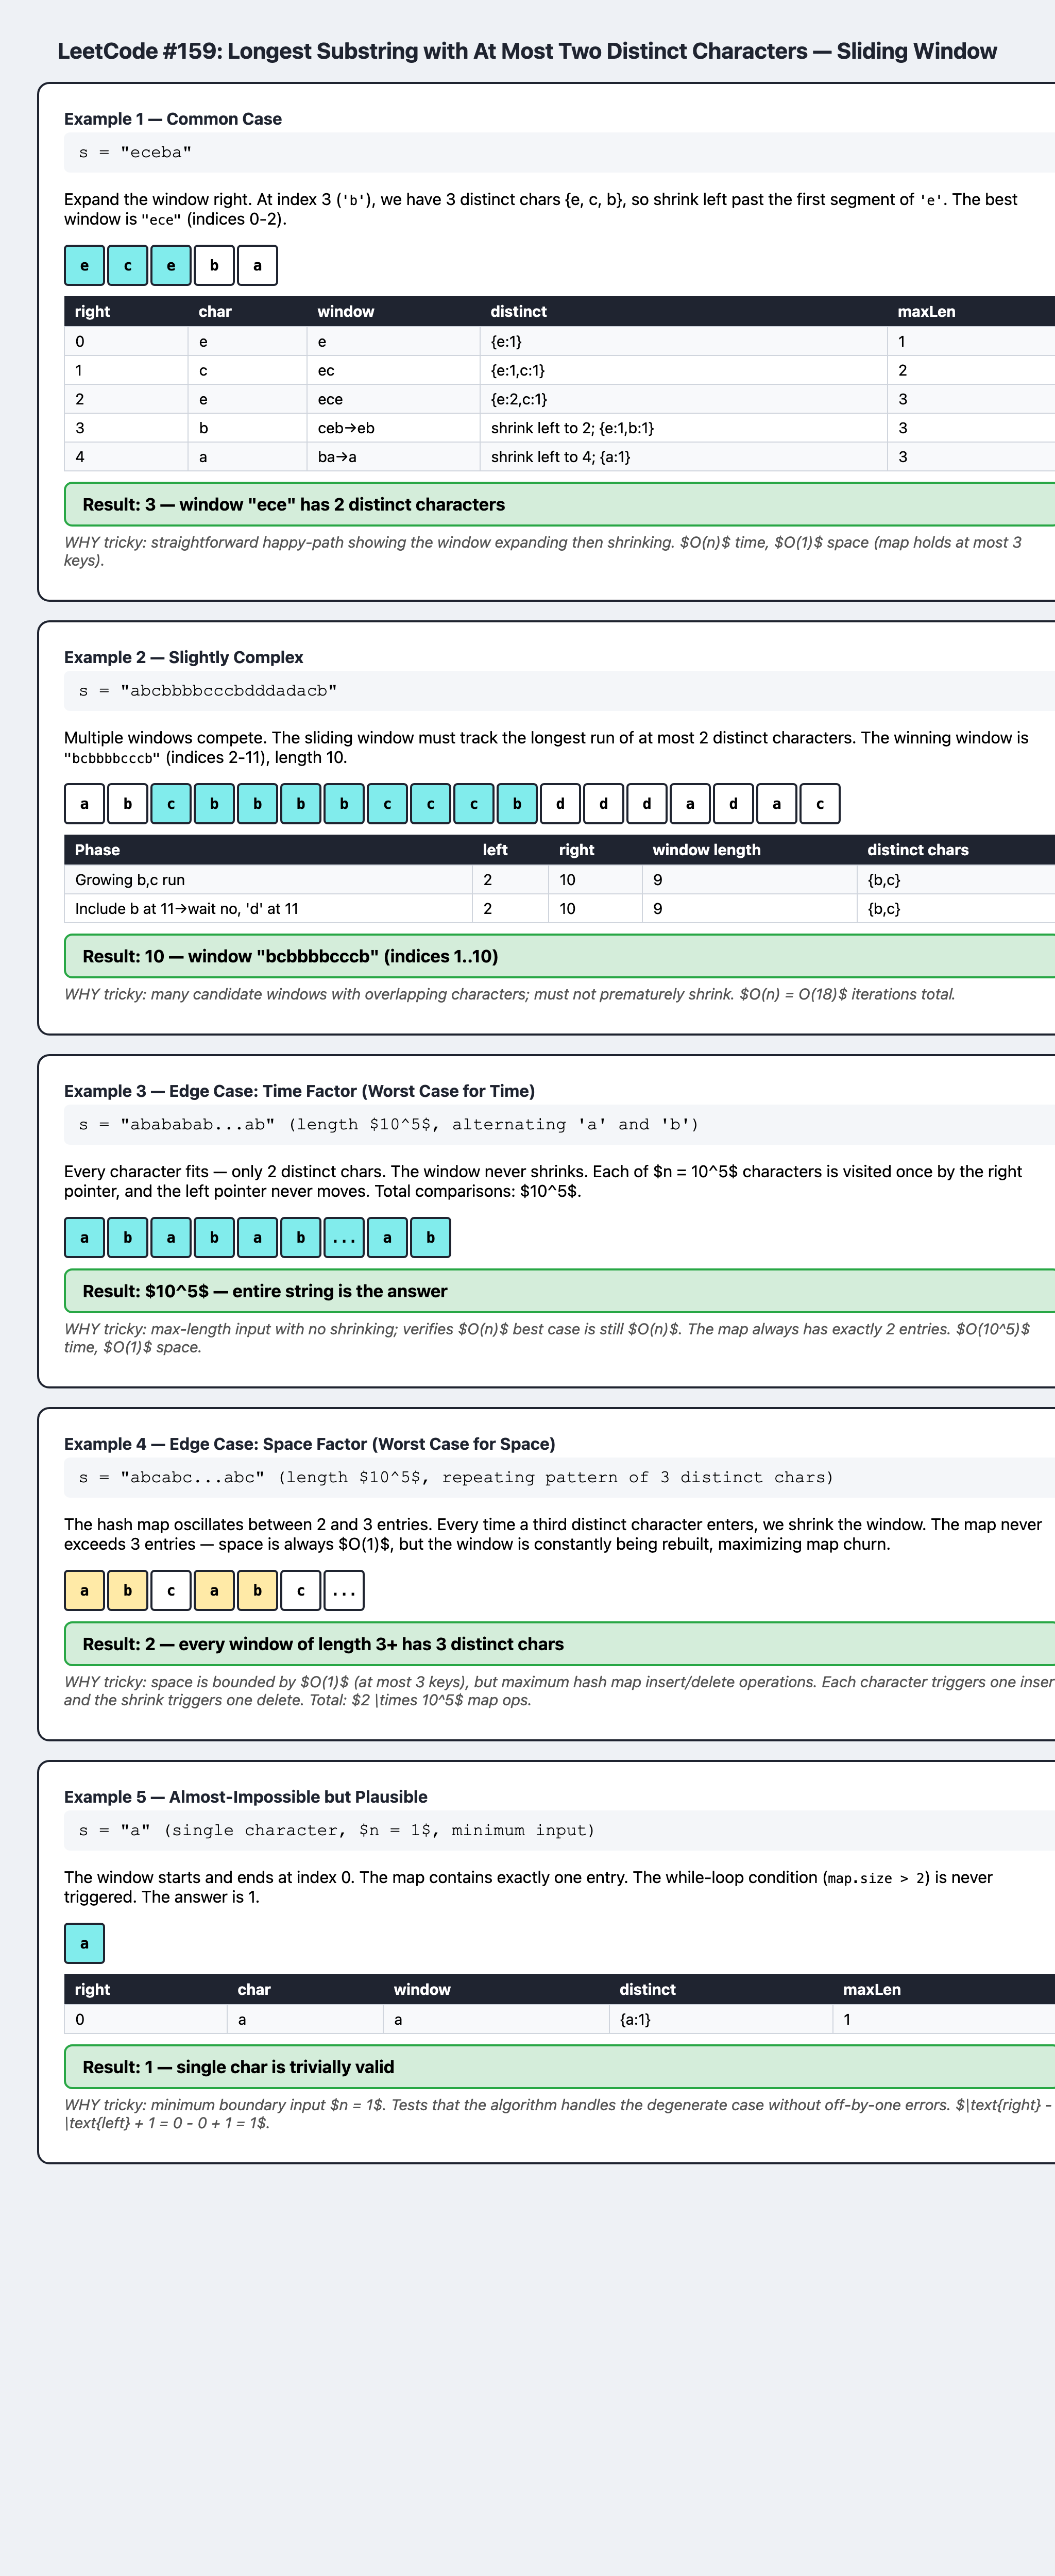